<a href="https://colab.research.google.com/github/NadiaTeta/group1/blob/main/notebooks/00_presentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inside GPT-2: How a Transformer Works, Part by Part
**Group 1 — Transformers Week**

We explore OpenAI's **GPT-2 (small, 124 million parameters)** to see how each part of the transformer works inside a real model, then compare it with the **tiny GPT** our group built from scratch and trained on Kinyarwanda news.

This notebook follows the path a sentence takes through GPT-2:

| # | Part | What it does | Notebook |
|---|---|---|---|
| 1 | Tokens | Splits text into pieces the model can read | `01_tokens_and_generation.ipynb` |
| 2 | Position embedding | Tells the model the order of the tokens | `02_position_embedding.ipynb` |
| 3 | Layer norm | Keeps the numbers at a steady size | `05_layer_norm.ipynb` |
| 4 | Attention | Lets tokens look at each other | `03_attention.ipynb` |
| 5 | Residual connections | Adds each step's result on top of what the token already had | `06_residual_connections.ipynb` |
| 6 | Feed-forward | Lets each token "think" on its own | `04_feed_forward.ipynb` |
| 7 | Text generation | Turns the final numbers into the next word | `01_tokens_and_generation.ipynb` |
| 8 | Tiny GPT vs GPT-2 | What's the same and what's different | — |

Each section contains only the **key experiment** from each member's notebook. The full work is in the individual notebooks in `notebooks/`.

**How to run:** turn on the GPU (*Runtime → Change runtime type → T4 GPU*), then *Runtime → Run all*. Results that use randomness may differ slightly from the individual notebooks.

## Setup
We load GPT-2 once and define the two example sentences everyone used: the same meaning in English and Kinyarwanda.

In [1]:
!pip install -q transformers

import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from contextlib import contextmanager
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained(
    "gpt2",
    output_attentions=True,         # lets us look at attention weights
    output_hidden_states=True,      # lets us look at the numbers after each layer
    attn_implementation="eager",    # needed so attention weights can be returned
).to(device)
model.eval()

print("Device:", device)
print(f"GPT-2 loaded: {sum(p.numel() for p in model.parameters()) / 1e6:.0f} million parameters")

english = "The people of Kicukiro say they have not had water for three days."
kinyarwanda = "Abaturage bo mu Kicukiro bavuga ko bamaze iminsi itatu nta mazi bafite."

def compute_loss(text, m=None, **kwargs):
    """How surprised the model is by a sentence (lower = better at predicting it)."""
    m = m or model
    enc = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        return m(**enc, labels=enc["input_ids"], **kwargs).loss.item()

print(f"\nLoss on English sentence:     {compute_loss(english):.2f}")
print(f"Loss on Kinyarwanda sentence: {compute_loss(kinyarwanda):.2f}")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Device: cuda
GPT-2 loaded: 124 million parameters


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.



Loss on English sentence:     4.46
Loss on Kinyarwanda sentence: 7.35


GPT-2 finds the Kinyarwanda sentence much harder to predict than the English one (a higher loss), because it was trained almost only on English text. We'll see why in the first section.

## 1. Tokens: splitting text into pieces
*From `01_tokens_and_generation.ipynb`*

GPT-2 doesn't read whole words. It splits text into **tokens**, pieces of words it learned from English text. It has about 50,000 of them. Common English words are usually one token, but unfamiliar words get chopped into several pieces.

In [2]:
rows = []
for name, s in [("English", english), ("Kinyarwanda", kinyarwanda)]:
    n_tokens = len(tokenizer.encode(s))
    n_words = len(s.split())
    rows.append({"language": name, "words": n_words, "tokens": n_tokens,
                 "tokens per word": round(n_tokens / n_words, 2)})
display(pd.DataFrame(rows))
print(f"Kinyarwanda needs {rows[1]['tokens'] / rows[0]['tokens']:.2f}x as many tokens as English.\n")

print("The same word in both languages:")
for en, rw in [("water", "amazi"), ("three", "itatu"), ("days", "iminsi"), ("say", "bavuga")]:
    print(f"{en:>8}: {tokenizer.tokenize(' ' + en)}")
    print(f"{rw:>8}: {tokenizer.tokenize(' ' + rw)}")

,language,words,tokens,tokens per word
0,English,13,17,1.31
1,Kinyarwanda,12,29,2.42


Kinyarwanda needs 1.71x as many tokens as English.

The same word in both languages:
   water: ['Ġwater']
   amazi: ['Ġam', 'azi']
   three: ['Ġthree']
   itatu: ['Ġit', 'atu']
    days: ['Ġdays']
  iminsi: ['Ġim', 'ins', 'i']
     say: ['Ġsay']
  bavuga: ['Ġb', 'av', 'uga']


**What we found:** English words like "water" are a single token, but Kinyarwanda words are chopped into pieces ("amazi" → "am" + "azi"). The Kinyarwanda sentence needs about **1.7× as many tokens**, which partly explains why GPT-2 handles it so badly.

**Compared with our tiny GPT:** our tiny GPT used single **characters** as tokens: just **78** (letters, digits and punctuation), compared with GPT-2's ~50,000 word pieces. Every Kinyarwanda word is spelled out letter by letter, so it never has this splitting problem, but it has to learn spelling from scratch.

## 2. Position embedding: knowing the order
*From `02_position_embedding.ipynb`*

Attention looks at all tokens at once, so on its own it doesn't know which token came first. GPT-2 fixes this with a **position embedding**: a learned table with one set of 768 numbers for each of its 1,024 positions, added to each token's numbers.

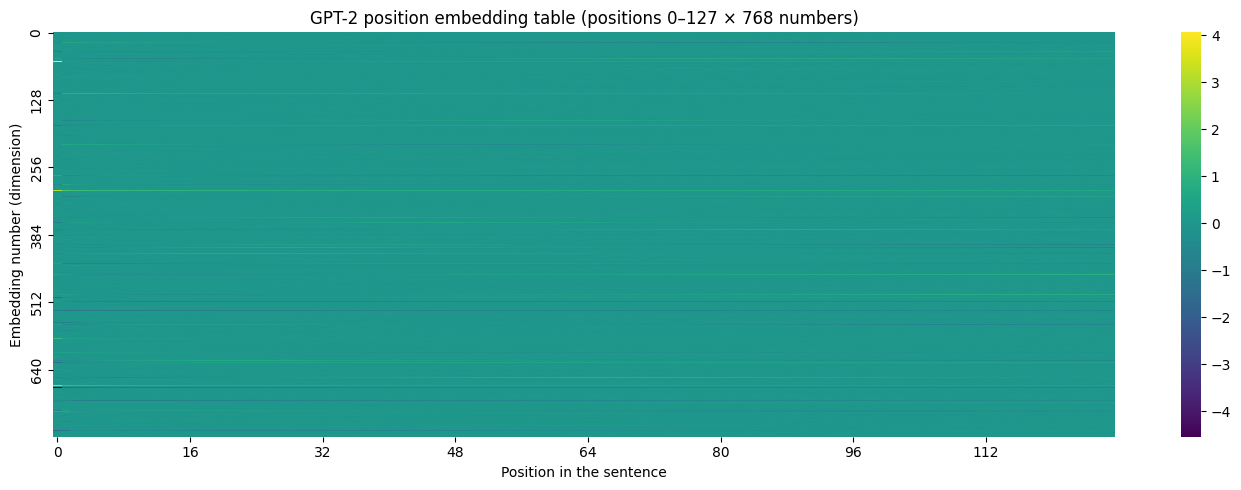

In [3]:
pos_embedding_matrix = model.transformer.wpe.weight.detach().cpu().numpy()

plt.figure(figsize=(14, 5))
sns.heatmap(pos_embedding_matrix[:128, :].T, cmap="viridis", cbar=True,
            xticklabels=16, yticklabels=128)
plt.title("GPT-2 position embedding table (positions 0–127 × 768 numbers)")
plt.xlabel("Position in the sentence")
plt.ylabel("Embedding number (dimension)")
plt.tight_layout()
plt.show()

Position 0 stands out with its own distinct pattern (a strong "start of text" signal), while neighbouring positions look similar to each other, so the representation changes gradually from one position to the next.

**Experiment:** keep the words exactly the same and in the same order, but scramble the **position numbers** GPT-2 receives. If the loss rises, GPT-2 really depends on the position embedding.

In [4]:
inputs = tokenizer(english, return_tensors="pt").to(device)
n = inputs["input_ids"].shape[1]
normal_loss = compute_loss(english)

scrambled_losses = []
for seed in range(5):
    torch.manual_seed(seed)
    perm = torch.randperm(n, device=device).unsqueeze(0)
    scrambled_losses.append(compute_loss(english, position_ids=perm))

print(f"Loss with correct positions:   {normal_loss:.2f}")
print(f"Loss with scrambled positions: {[round(l, 2) for l in scrambled_losses]}")
print(f"Average scrambled loss:        {np.mean(scrambled_losses):.2f}")

Loss with correct positions:   4.46
Loss with scrambled positions: [9.56, 8.3, 9.99, 10.6, 10.31]
Average scrambled loss:        9.75


**What we found:** with the positions scrambled, the loss roughly **doubles**, even though the words themselves are correct. GPT-2 relies heavily on the position embedding to understand the sentence.

**Compared with our tiny GPT:** our tiny GPT used exactly the same idea, a learned position table, but with only **64 positions** (64 characters, roughly 10 words) instead of GPT-2's 1,024 tokens, so it can only look back a short distance.

## 3. Layer norm: keeping the numbers steady
*From `05_layer_norm.ipynb`*

Each of GPT-2's 12 blocks has two layer norms (`ln_1` before attention, `ln_2` before feed-forward), plus one final layer norm: **25 in total**. Layer norm rescales each token's numbers to a steady range before each step.

**Experiment:** measure the size of each token's numbers going into and coming out of `ln_1`, in all 12 blocks.

Layer | size before LN | size after LN
    0 |            5.1 |           2.9
    1 |           54.5 |           4.1
    2 |           56.2 |           7.7
    3 |           60.9 |           9.5
    4 |           66.6 |           8.9
    5 |           72.4 |          10.6
    6 |           78.8 |           9.9
    7 |           89.2 |           9.9
    8 |          104.6 |           9.2
    9 |          126.3 |           8.9
   10 |          159.7 |           8.3
   11 |          245.6 |           7.7


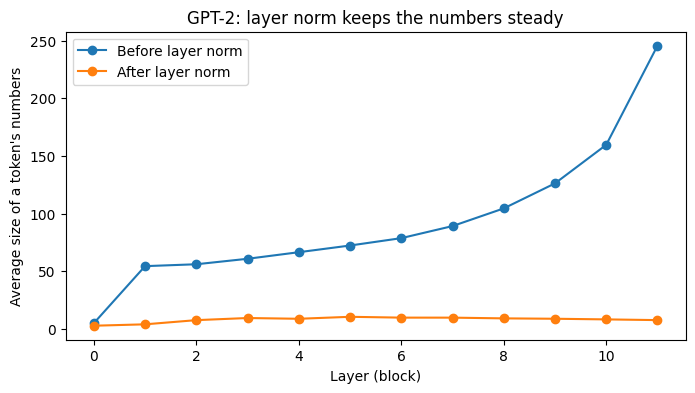

First token's size before layer norm, per layer: [10, 133, 636, 2564, 2748, 2897, 2991, 3046, 3080, 3101, 3111, 3112]


In [5]:
before, after, first_token = [], [], []

def make_hook():
    def hook(module, inp, outp):
        b, a = inp[0][0], outp[0]
        before.append(b[1:].norm(dim=-1).mean().item())   # average size, skipping the first token
        after.append(a[1:].norm(dim=-1).mean().item())
        first_token.append(b[0].norm().item())            # first token measured separately
    return hook

hooks = [block.ln_1.register_forward_hook(make_hook()) for block in model.transformer.h]
with torch.no_grad():
    model(**inputs)
for h in hooks:
    h.remove()

print("Layer | size before LN | size after LN")
for i in range(12):
    print(f"{i:5} | {before[i]:14.1f} | {after[i]:13.1f}")

plt.figure(figsize=(8, 4))
plt.plot(range(12), before, marker="o", label="Before layer norm")
plt.plot(range(12), after, marker="o", label="After layer norm")
plt.xlabel("Layer (block)")
plt.ylabel("Average size of a token's numbers")
plt.title("GPT-2: layer norm keeps the numbers steady")
plt.legend()
plt.show()

print("First token's size before layer norm, per layer:", [round(v) for v in first_token])

**What we found:** the numbers grow about **48 times** larger from the first block to the last (because residual connections keep adding to each token), but after layer norm they always stay in a small, steady range. The first token grows even more, to over 3,000. This is the "attention sink" token, which also shows up in the attention section.

**Experiment:** what happens if we remove the layer norms?

In [6]:
def continue_text(m, prompt, n=20):
    enc = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = m.generate(**enc, max_new_tokens=n, do_sample=False,
                         pad_token_id=tokenizer.eos_token_id,
                         output_attentions=False, output_hidden_states=False)
    return tokenizer.decode(out[0])

no_ln = copy.deepcopy(model)              # a copy, so the original GPT-2 stays untouched
for block in no_ln.transformer.h:
    block.ln_1 = torch.nn.Identity()      # Identity = "do nothing", i.e. layer norm removed
    block.ln_2 = torch.nn.Identity()

print(f"Loss WITH layer norm:    {compute_loss(english):.2f}")
print(f"Loss WITHOUT layer norm: {compute_loss(english, m=no_ln):.2f}")

prompt = "The people of Kicukiro say"
print("\nWITH layer norm:   ", continue_text(model, prompt))
print("WITHOUT layer norm:", continue_text(no_ln, prompt))

del no_ln   # free the memory

Loss WITH layer norm:    4.46
Loss WITHOUT layer norm: nan

WITH layer norm:    The people of Kicukiro say that the city is a place of peace and harmony.

"We are not afraid of the
WITHOUT layer norm: The people of Kicukiro say!!!!!!!!!!!!!!!!!!!!


**What we found:** without layer norm, the loss becomes `nan` ("not a number"): the numbers grow so large that the calculations break, and GPT-2 only writes "!!!!!". GPT-2 was trained with layer norm, so it depends on it completely.

**Compared with our tiny GPT:** our tiny GPT used the same layer norm before attention and feed-forward in each of its **4 blocks** (plus a final one), exactly like GPT-2's design. With 4 blocks instead of 12, the numbers have less room to grow, but the purpose is the same.

## 4. Attention: tokens looking at each other
*From `03_attention.ipynb`*

Attention is the only part of the transformer where tokens share information. GPT-2 has **12 layers × 12 heads = 144 attention heads**. Each head learns its own pattern of what to look at.

**Experiment:** search all 144 heads for clear patterns.

In [7]:
with torch.no_grad():
    attentions = model(**inputs).attentions
input_tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
num_layers, num_heads = len(attentions), attentions[0].shape[1]
print(f"{num_layers} layers x {num_heads} heads, sentence of {len(input_tokens)} tokens\n")

prev_token_scores, first_token_scores = [], []
for layer in range(num_layers):
    layer_attn = attentions[layer][0].cpu().numpy()
    for head in range(num_heads):
        m = layer_attn[head]
        prev_token_scores.append((np.mean([m[i, i - 1] for i in range(1, n)]), layer, head))
        first_token_scores.append((np.mean(m[1:, 0]), layer, head))

prev_token_scores.sort(reverse=True)
first_token_scores.sort(reverse=True)

print("Heads that look at the PREVIOUS token:")
for score, layer, head in prev_token_scores[:3]:
    print(f"  Layer {layer}, Head {head}: {score:.4f}")
print("\nHeads that look at the FIRST token (attention sink):")
for score, layer, head in first_token_scores[:3]:
    print(f"  Layer {layer}, Head {head}: {score:.4f}")

12 layers x 12 heads, sentence of 17 tokens

Heads that look at the PREVIOUS token:
  Layer 4, Head 11: 0.9998
  Layer 2, Head 2: 0.5500
  Layer 3, Head 3: 0.4208

Heads that look at the FIRST token (attention sink):
  Layer 5, Head 1: 0.9989
  Layer 7, Head 2: 0.9975
  Layer 6, Head 9: 0.9966


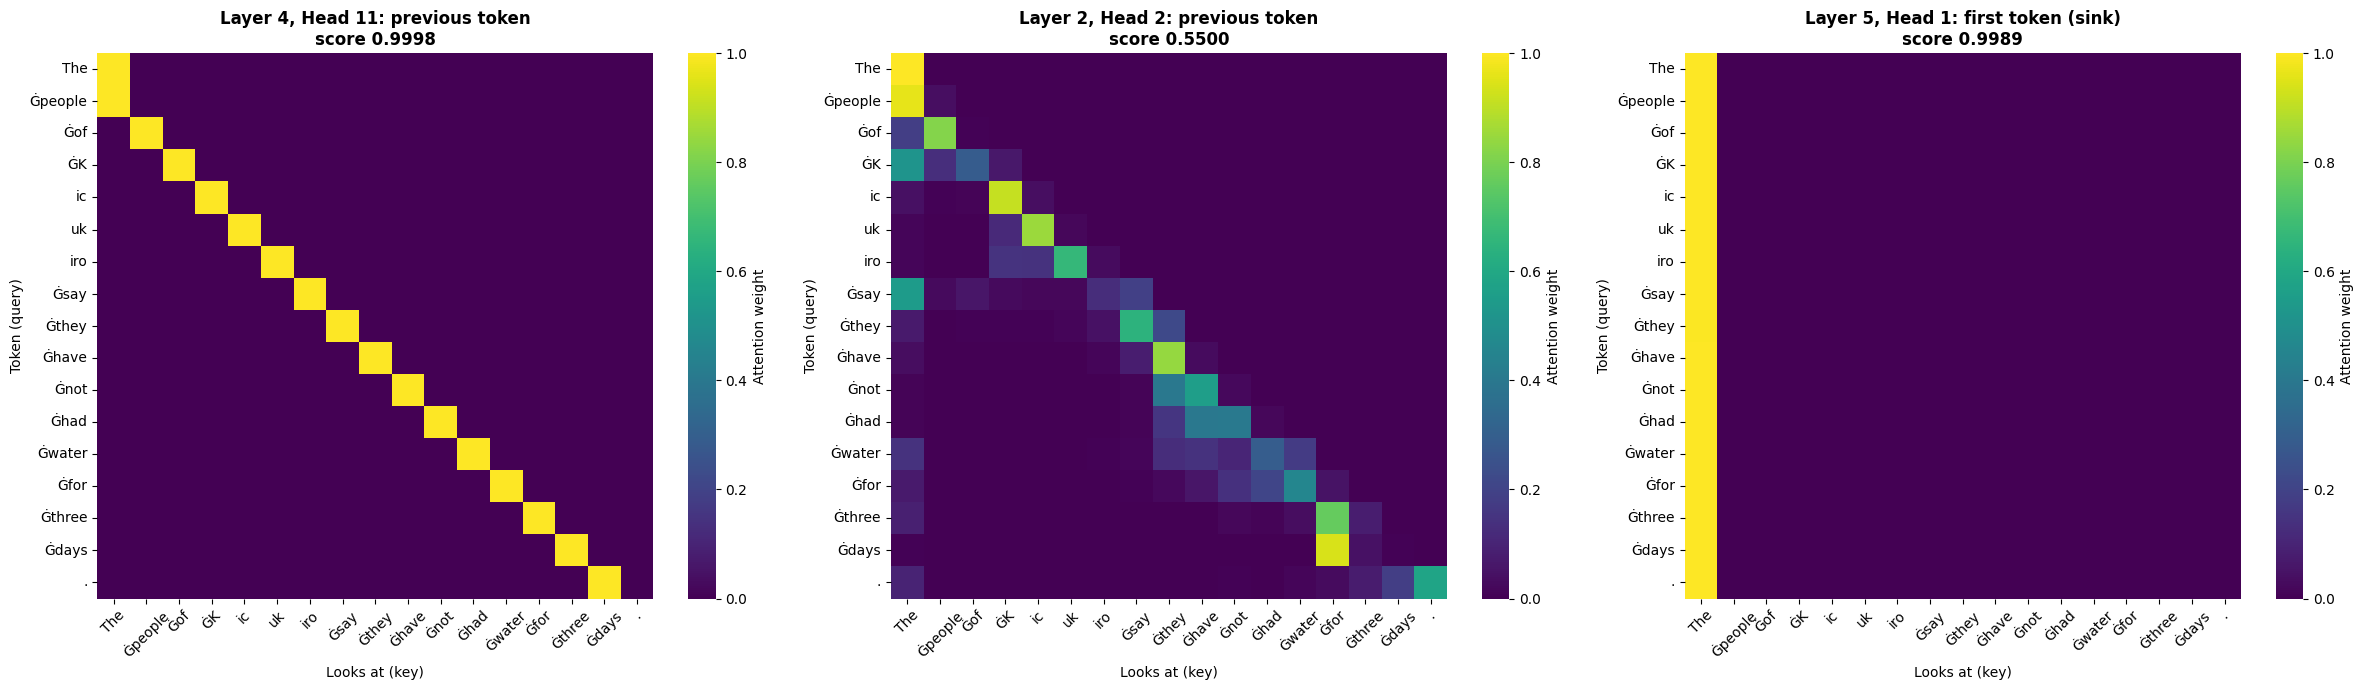

In [8]:
(p_score, p_layer, p_head), (s_score, s_layer, s_head) = prev_token_scores[0], prev_token_scores[1]
f_score, f_layer, f_head = first_token_scores[0]

heads_to_plot = [
    (p_layer, p_head, f"Layer {p_layer}, Head {p_head}: previous token\nscore {p_score:.4f}"),
    (s_layer, s_head, f"Layer {s_layer}, Head {s_head}: previous token\nscore {s_score:.4f}"),
    (f_layer, f_head, f"Layer {f_layer}, Head {f_head}: first token (sink)\nscore {f_score:.4f}"),
]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
for ax, (layer, head, title) in zip(axes, heads_to_plot):
    sns.heatmap(attentions[layer][0, head].cpu().numpy(), xticklabels=input_tokens,
                yticklabels=input_tokens, cmap="viridis", ax=ax,
                cbar_kws={"label": "Attention weight"})
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Looks at (key)")
    ax.set_ylabel("Token (query)")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

In [9]:
# Does the previous-token head behave the same on Kinyarwanda?
rw_inputs = tokenizer(kinyarwanda, return_tensors="pt").to(device)
with torch.no_grad():
    rw_attn = model(**rw_inputs).attentions
rw_n = rw_inputs["input_ids"].shape[1]

for name, attn, length in [("English", attentions, n), ("Kinyarwanda", rw_attn, rw_n)]:
    m = attn[p_layer][0, p_head].cpu().numpy()
    score = np.mean([m[i, i - 1] for i in range(1, length)])
    print(f"{name}: Layer {p_layer}, Head {p_head} previous-token score = {score:.4f} ({length} tokens)")

English: Layer 4, Head 11 previous-token score = 0.9998 (17 tokens)
Kinyarwanda: Layer 4, Head 11 previous-token score = 0.9999 (29 tokens)


**What we found:**
- One head (Layer 4, Head 11) puts almost **100%** of its attention on the **previous token**, and works just as well on Kinyarwanda, where it may help stitch word pieces back together.
- Several middle-layer heads send almost all their attention to the **first token**. This "attention sink" is a resting place for heads with nothing useful to look at, and it connects with the layer norm result, where the first token had huge numbers.

**Compared with our tiny GPT:** our tiny GPT has **4 blocks × 4 heads = 16 attention heads**, each working with 32 numbers. GPT-2 has **144 heads** of 64 numbers each, which gives it room for specialised heads like the ones above.

## 5. Residual connections: adding, not replacing
*From `06_residual_connections.ipynb`*

Each attention and feed-forward step **adds** its result to the token's running total, called the **residual stream**, instead of replacing it. So information builds up layer by layer.

**Experiment ("logit lens"):** give GPT-2 our sentence with the last word removed. After each of the 12 layers, take the residual stream of the last token and ask: *"if GPT-2 stopped here, what word would it predict?"* This lets us watch the prediction form inside the model.

In [10]:
# The shared sentences, with the LAST word removed. The model has to guess that missing word.
english_prompt = "The people of Kicukiro say they have not had water for three"
english_answer = " days"

kiny_prompt = "Abaturage bo mu Kicukiro bavuga ko bamaze iminsi itatu nta mazi"
kiny_answer = " bafite"

def residual_stream_lens(prompt, correct_word):
    enc = tokenizer(prompt, return_tensors="pt").to(device)

    # The ID of the correct word's FIRST token (a long word can be split into several tokens,
    # and the model predicts one token at a time).
    correct_id = tokenizer.encode(correct_word)[0]

    # hidden_states = the residual stream after the embeddings and after each of the 12 layers
    with torch.no_grad():
        snapshots = model(**enc).hidden_states
    num_layers = len(model.transformer.h)

    rows = []
    for i, snapshot in enumerate(snapshots):
        vector = snapshot[0, -1]                        # the last token predicts the next word
        if i < num_layers:                              # the last snapshot already has the
            vector = model.transformer.ln_f(vector)     # final layer norm applied
        probs = torch.softmax(model.lm_head(vector), dim=-1)
        top_prob, top_id = probs.max(dim=-1)
        rows.append({
            "stopped after": "embeddings" if i == 0 else f"layer {i}",
            "top guess": repr(tokenizer.decode(top_id)),
            "confidence": f"{top_prob.item():.1%}",
            "chance of correct word": f"{probs[correct_id].item():.2%}",
        })
    return pd.DataFrame(rows)

print("ENGLISH (correct word:", repr(english_answer), ")")
english_table = residual_stream_lens(english_prompt, english_answer)
print(english_table.to_string(index=False))

print("\nKINYARWANDA (correct word:", repr(kiny_answer), ")")
kiny_table = residual_stream_lens(kiny_prompt, kiny_answer)
print(kiny_table.to_string(index=False))

ENGLISH (correct word: ' days' )
stopped after      top guess confidence chance of correct word
   embeddings    ' challeng'      51.6%                  0.00%
      layer 1         'teen'      42.6%                  1.20%
      layer 2         'teen'      32.4%                  0.82%
      layer 3     ' hundred'      26.5%                  1.72%
      layer 4     ' hundred'      37.0%                  1.63%
      layer 5       ' weeks'      27.6%                  1.64%
      layer 6 ' consecutive'      22.7%                  1.94%
      layer 7      ' months'      40.4%                  4.53%
      layer 8      ' months'      36.1%                  2.63%
      layer 9      ' months'      54.9%                  1.93%
     layer 10      ' months'      56.6%                  2.82%
     layer 11      ' months'      39.2%                  9.88%
     layer 12       ' years'      34.1%                 18.04%

KINYARWANDA (correct word: ' bafite' )
stopped after top guess confidence chance of 

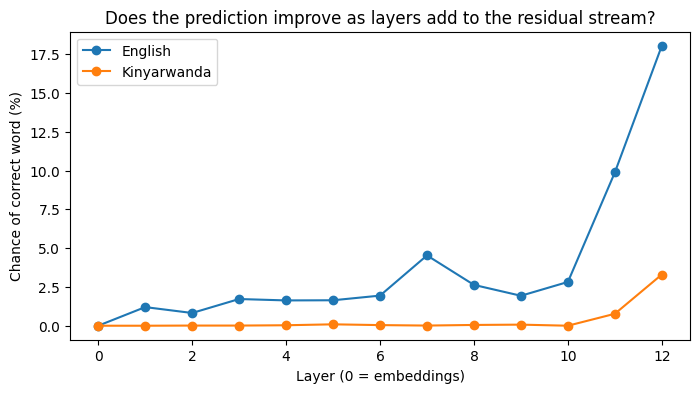

In [11]:
def to_number(col):
    return [float(x.strip("%")) for x in col]

plt.figure(figsize=(8, 4))
plt.plot(to_number(english_table["chance of correct word"]), marker="o", label="English")
plt.plot(to_number(kiny_table["chance of correct word"]), marker="o", label="Kinyarwanda")
plt.xlabel("Layer (0 = embeddings)")
plt.ylabel("Chance of correct word (%)")
plt.title("Does the prediction improve as layers add to the residual stream?")
plt.legend()
plt.show()

**What we found:**
- **English:** the prediction takes shape layer by layer. Early layers guess word fragments, middle layers move to numbers ("hundred"), and from around layer 5 GPT-2 switches to **time words** ("weeks", "months", "years"). The chance of the correct word, "days", grows from **0% to about 18%**. GPT-2's final top guess is "years", but "days" is clearly being built up. Because each layer only *adds* to the stream, earlier understanding ("a time unit comes next") is kept and refined.
- **Kinyarwanda:** the guesses jump between meaningless pieces, and the chance of the correct word stays near zero. Note: "bafite" is split into several tokens, and this test only checks the first piece (" b"), which is very common, so the small rise at the end doesn't mean GPT-2 understood the sentence.

**Compared with our tiny GPT:** our tiny GPT used the same residual connections (`x = x + attention(...)` and `x = x + feed_forward(...)`) in each block. They are what make it possible to stack many blocks without losing the original information.

## 6. Feed-forward: each token thinks on its own
*From `04_feed_forward.ipynb`*

After attention, each token passes through a small neural network on its own: 768 numbers → 3,072 → back to 768. Researchers believe this is where a lot of knowledge and language patterns are stored (Geva et al., 2021).

**Experiment:** switch off the feed-forward part of each layer, one at a time, and see how much worse GPT-2 gets.

Layer  0 | English: +3.7631 | Kinyarwanda: +0.7502
Layer  1 | English: +0.0144 | Kinyarwanda: +0.0812
Layer  2 | English: +0.1479 | Kinyarwanda: +0.0639
Layer  3 | English: +0.0344 | Kinyarwanda: -0.0663
Layer  4 | English: +0.1672 | Kinyarwanda: -0.0756
Layer  5 | English: +0.0295 | Kinyarwanda: -0.0299
Layer  6 | English: +0.0470 | Kinyarwanda: -0.0782
Layer  7 | English: +0.1142 | Kinyarwanda: -0.0578
Layer  8 | English: +0.1607 | Kinyarwanda: +0.0384
Layer  9 | English: +0.1323 | Kinyarwanda: -0.0491
Layer 10 | English: -0.0846 | Kinyarwanda: +0.0177
Layer 11 | English: +0.2623 | Kinyarwanda: +0.7264


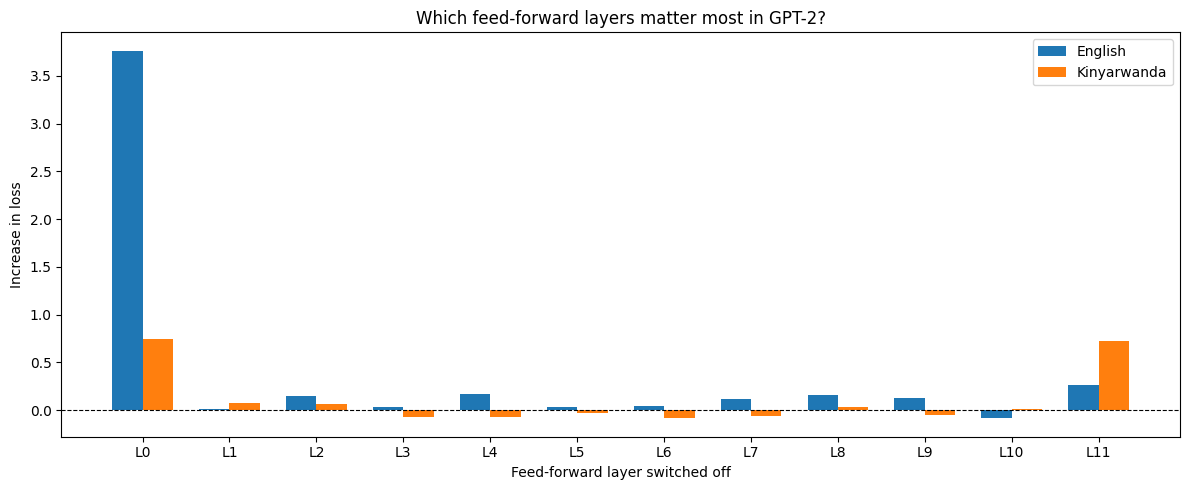

In [12]:
@contextmanager
def mute_mlp(layer_idx):
    """Temporarily replace one layer's feed-forward output with zeros."""
    mlp = model.transformer.h[layer_idx].mlp
    original_forward = mlp.forward
    mlp.forward = lambda *args, **kwargs: torch.zeros_like(original_forward(*args, **kwargs))
    try:
        yield
    finally:
        mlp.forward = original_forward

baseline_eng, baseline_kin = compute_loss(english), compute_loss(kinyarwanda)
eng_increases, kin_increases = [], []
for layer in range(12):
    with mute_mlp(layer):
        eng_increases.append(compute_loss(english) - baseline_eng)
        kin_increases.append(compute_loss(kinyarwanda) - baseline_kin)
    print(f"Layer {layer:2d} | English: {eng_increases[-1]:+.4f} | Kinyarwanda: {kin_increases[-1]:+.4f}")

x = np.arange(12)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.175, eng_increases, 0.35, label="English")
ax.bar(x + 0.175, kin_increases, 0.35, label="Kinyarwanda")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels([f"L{i}" for i in range(12)])
ax.set_xlabel("Feed-forward layer switched off")
ax.set_ylabel("Increase in loss")
ax.set_title("Which feed-forward layers matter most in GPT-2?")
ax.legend()
plt.tight_layout()
plt.show()

**What we found:** switching off **Layer 0** breaks GPT-2 far more than any other layer (+3.76 for English). The last layer (11) also matters, especially for Kinyarwanda. Most middle layers change very little. These results come from one sentence per language, so small differences may just be noise.

**Compared with our tiny GPT:** our tiny GPT used the same design, expanding to 4× the size and shrinking back, but much smaller: **128 → 512 → 128** numbers, compared with GPT-2's 768 → 3,072 → 768. One small difference: it uses the ReLU activation, while GPT-2 uses GELU.

## 7. Text generation: writing the next word
*From `01_tokens_and_generation.ipynb`*

At the end, GPT-2 turns the last token's numbers into a probability for each of its ~50,000 tokens and picks one. **Temperature** controls how adventurous it is: low = safe and repetitive, high = creative and chaotic.

In [13]:
def generate(prompt, temperature, max_new_tokens=40, seed=42):
    torch.manual_seed(seed)   # same seed each time, so only temperature changes
    enc = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.generate(**enc, do_sample=True, temperature=temperature, top_k=0, top_p=1.0,
                             max_new_tokens=max_new_tokens, pad_token_id=tokenizer.eos_token_id,
                             output_attentions=False, output_hidden_states=False)
    return tokenizer.decode(out[0], skip_special_tokens=True)

for p in ["The people of Kicukiro say", "Abaturage bo mu Kicukiro bavuga ko"]:
    print("=" * 70)
    print("PROMPT:", p)
    for t in [0.2, 0.7, 1.5]:
        print(f"\n--- temperature {t} ---")
        print(generate(p, t))
    print()

PROMPT: The people of Kicukiro say

--- temperature 0.2 ---
The people of Kicukiro say they are not afraid of the police, but they are afraid of the people of Kicukiro.

"We are not afraid of the police. We are afraid of the people of K

--- temperature 0.7 ---
The people of Kicukiro say they are not afraid of being attacked, but they are afraid of being attacked by the mob, because they are scared of the public opinion, because they are afraid of the mob, because they are afraid

--- temperature 1.5 ---
The people of Kicukiro say none the less that protagonist Akira Yen posted nostalgia to storage boxes in hopes spreading it all laugh at Yamonen Nation 6 Internet (TCIIIIKIN WILL YOU PAT That brilliant stall class Kikiamond

PROMPT: Abaturage bo mu Kicukiro bavuga ko

--- temperature 0.2 ---
Abaturage bo mu Kicukiro bavuga ko kunai.

Kunai ko kunai.

Kunai ko kunai.

Kunai ko kunai.

Kunai ko

--- temperature 0.7 ---
Abaturage bo mu Kicukiro bavuga ko ji no ko kunu, siya na ngayon ko k

**What we found:** at low temperature, GPT-2 repeats itself; around 0.7 it writes fluent English; at 1.5 it becomes nonsense. Given a Kinyarwanda prompt, it can't continue properly in Kinyarwanda.

**Compared with our tiny GPT:** our tiny GPT writes Kinyarwanda-looking text because it was trained on Kinyarwanda news. Given the prompt "Ikipe", it wrote: *"Ikipe ye ya Afurika y'ingendo z'ibikorwa n'igitabo gitero cya mbere na Maria Commosiaria waba ari uwarambutse abaturage..."* Many words are real Kinyarwanda, but the sentence doesn't make sense. GPT-2 writes fluent English but can't continue in Kinyarwanda. Size matters, but so does the training data.

## 8. Our tiny GPT vs GPT-2
Both use the **same design**: token embedding + position embedding, then blocks of layer norm → attention → residual → layer norm → feed-forward → residual. The difference is mostly **size** and **training data**.

In [14]:
cfg = model.config
gpt2 = {
    "Tokens": f"word pieces ({cfg.vocab_size:,})",
    "Blocks (layers)": cfg.n_layer,
    "Attention heads per block": cfg.n_head,
    "Total attention heads": cfg.n_layer * cfg.n_head,
    "Numbers per token (embedding size)": cfg.n_embd,
    "Context length": f"{cfg.n_positions} tokens",
    "Parameters": f"{sum(p.numel() for p in model.parameters()) / 1e6:.0f} million",
    "Training data": "~40 GB of English web text",
}

tiny_gpt = {   # from our tiny GPT notebook (gpt/Tiny_gpt.ipynb)
    "Tokens": "characters (78)",
    "Blocks (layers)": 4,
    "Attention heads per block": 4,
    "Total attention heads": 16,
    "Numbers per token (embedding size)": 128,
    "Context length": "64 characters",
    "Parameters": "0.82 million",
    "Training data": "~24 million characters of Kinyarwanda news (KINNEWS)",
}

display(pd.DataFrame({"Our tiny GPT": tiny_gpt, "GPT-2 (small)": gpt2}))

,Our tiny GPT,GPT-2 (small)
Tokens,characters (78),"word pieces (50,257)"
Blocks (layers),4,12
Attention heads per block,4,12
Total attention heads,16,144
Numbers per token (embedding size),128,768
Context length,64 characters,1024 tokens
Parameters,0.82 million,124 million
Training data,~24 million characters of Kinyarwanda news (KI...,~40 GB of English web text


**Training:** our tiny GPT trained for 5,000 steps (batches of 64 chunks of 64 characters) and reached a training loss of about **1.40**. This number can't be compared directly with GPT-2's losses above, because our tiny GPT predicts one *character* at a time (78 options), while GPT-2 predicts one *word piece* at a time (~50,000 options).

**In short:** GPT-2 is our tiny GPT scaled up about 150 times and trained on far more text. The design is the same; the size and the training data are what make the difference.

### Key findings
1. **Tokens:** Kinyarwanda needs about 1.7× as many GPT-2 tokens as English, because GPT-2's tokens were learned from English.
2. **Position embedding:** scrambling only the positions roughly doubles the loss, so word order really matters to GPT-2.
3. **Layer norm:** the numbers grow about 48× through the layers; layer norm keeps them steady, and removing it breaks GPT-2 completely.
4. **Attention:** GPT-2 has specialised heads, like one that almost always looks at the previous token, and an "attention sink" on the first token.
5. **Residual connections:** layer by layer, GPT-2 builds its prediction in the residual stream: for English it moves from word fragments to numbers to time words, and the chance of the correct word ("days") grows from 0% to about 18%. For Kinyarwanda it never gets there.
6. **Feed-forward:** the first layer's feed-forward is by far the most important; most middle layers matter little.
7. **Generation and comparison:** same design as our tiny GPT, but about 150× bigger (124 million vs 0.82 million parameters) and trained on English, so it writes fluent English but not Kinyarwanda.

### Sources
- Radford et al. (2019). *Language Models are Unsupervised Multitask Learners* (GPT-2).
- Vaswani et al. (2017). *Attention Is All You Need.* https://arxiv.org/abs/1706.03762
- Geva et al. (2021). *Transformer Feed-Forward Layers Are Key-Value Memories.* https://arxiv.org/abs/2012.14913
- nostalgebraist (2020). *Interpreting GPT: the logit lens.* https://www.lesswrong.com/posts/AcKRB8wDpdaN6v6ru/interpreting-gpt-the-logit-lens
- Hugging Face Transformers documentation: https://huggingface.co/docs/transformers